DataView: Exploração e Análise de Dados de Vendas

Célula 1 — imports (no notebook)
Bloco de importação de bibliotecas

In [7]:
import pandas as pd
import numpy as np
import random
import os
import json

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime, timedelta

## RF01 – Criação do Dataset de Vendas

Nesta etapa é gerado um dataset sintético contendo informações de vendas e inconsistências intencionais, que serão tratadas nas etapas seguintes.

Célula 2 — função para gerar dataset

In [8]:
def gerar_dataset_vendas(n_registros=150, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    produtos = ["Notebook", "Smartphone", "Tablet", "Monitor", "Teclado", "Mouse"]

    precos = {
        "Notebook": 3500,
        "Smartphone": 2200,
        "Tablet": 1800,
        "Monitor": 1200,
        "Teclado": 250,
        "Mouse": 120
    }

    categorias = {
        "Notebook": "Computadores",
        "Smartphone": "Celulares",
        "Tablet": "Celulares",
        "Monitor": "Computadores",
        "Teclado": "Periféricos",
        "Mouse": "Periféricos"
    }

    regioes = ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]
    clientes = [f"Cliente_{i:03d}" for i in range(1, 31)]

    data_inicio = datetime(2024, 1, 1)

    dados = []

    for i in range(n_registros):

        produto = random.choice(produtos)
        quantidade = random.randint(1, 10)
        preco = precos[produto]

        data = data_inicio + timedelta(days=random.randint(0, 364))

        # dados sujos (essenciais para RF03 depois)
        if random.random() < 0.05:
            quantidade = None         # valor nulo

        if random.random() < 0.04:
            preco = None             # valor nulo

        if random.random() < 0.03:
            produto = "  " + produto  # espaço extra (string suja)

        data_str = (
            data.strftime("%Y-%m-%d")
            if random.random() > 0.02
            else "DATA INVALIDA"
        )

        dados.append({
            "id_venda": i + 1,
            "data_venda": data_str,
            "cliente": random.choice(clientes),
            "produto": produto,
            "categoria": categorias.get(produto.strip(), "Outros"),
            "regiao": random.choice(regioes),
            "quantidade": quantidade,
            "preco_unitario": preco
        })

    return pd.DataFrame(dados)

Célula 3 — gerar dataset

In [9]:
# Gerar o dataset sintético de vendas
df_bruto = gerar_dataset_vendas()

# Visualizar os primeiros registros
df_bruto.head()

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-01-13,Cliente_024,Mouse,Periféricos,Norte,2.0,120.0
1,2,2024-08-04,Cliente_018,Notebook,Computadores,Sul,NaN,3500.0
2,3,DATA INVALIDA,Cliente_026,Mouse,Periféricos,Sul,9.0,120.0
3,4,2024-06-23,Cliente_013,Mouse,Periféricos,Sudeste,7.0,120.0
4,5,2024-11-05,Cliente_030,Tablet,Celulares,Centro-Oeste,6.0,1800.0


Célula 4 — salvar dataset bruto

In [10]:
os.makedirs("data/raw", exist_ok=True) # Adicionado para garantir que o diretório exista

df_bruto.to_csv("data/raw/vendas.csv", index=False)

print("✅ Dataset bruto salvo em: data/raw/vendas.csv")
print(f"📊 Dimensões: {df_bruto.shape[0]} linhas × {df_bruto.shape[1]} colunas")

✅ Dataset bruto salvo em: data/raw/vendas.csv
📊 Dimensões: 150 linhas × 8 colunas


## RF02 – Inspeção Inicial dos Dados

Nesta etapa é realizada uma análise exploratória do dataset para verificar sua estrutura, identificar valores ausentes, registros duplicados e compreender as características gerais dos dados antes do processo de limpeza.

Célula 5 – Função de inspeção

In [11]:
def inspecionar_dados(df):
    """
    Realiza uma inspeção inicial do DataFrame,
    apresentando estrutura, tipos de dados,
    valores ausentes e estatísticas descritivas.
    """

    print("\n=== INSPEÇÃO INICIAL DO DATASET ===")

    print(f"Shape: {df.shape}")

    print("\nColunas:")
    print(list(df.columns))

    print("\nTipos de dados:")
    print(df.dtypes)

    print("\nValores nulos por coluna:")
    print(df.isnull().sum())

    print("\nPrimeiros registros:")
    print(df.head())

    print("\nEstatísticas descritivas:")
    print(df.describe(include="all"))

    # Mediana das variáveis numéricas
    print("\nMediana das variáveis numéricas:")
    medianas = df.select_dtypes(include="number").median()
    print(medianas)

    duplicados = df.duplicated().sum()
    print(f"\nRegistros duplicados: {duplicados}")

    return df.describe(include="all")

Célula 6 – Execução da inspeção

In [12]:
estatisticas_iniciais = inspecionar_dados(df_bruto)

estatisticas_iniciais


=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (150, 8)

Colunas:
['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda            int64
data_venda            str
cliente               str
produto               str
categoria             str
regiao                str
quantidade        float64
preco_unitario    float64
dtype: object

Valores nulos por coluna:
id_venda          0
data_venda        0
cliente           0
produto           0
categoria         0
regiao            0
quantidade        5
preco_unitario    2
dtype: int64

Primeiros registros:
   id_venda     data_venda      cliente   produto     categoria        regiao  \
0         1     2024-01-13  Cliente_024     Mouse   Periféricos         Norte   
1         2     2024-08-04  Cliente_018  Notebook  Computadores           Sul   
2         3  DATA INVALIDA  Cliente_026     Mouse   Periféricos           Sul   
3         4     2024-06-23  Cliente_013     Mous

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
count,150.000000,150,150,150,150,150,145.000000,148.000000
unique,NaN,117,30,8,3,5,NaN,NaN
top,NaN,DATA INVALIDA,Cliente_018,Mouse,Celulares,Sudeste,NaN,NaN
freq,NaN,4,8,28,51,41,NaN,NaN
mean,75.500000,NaN,NaN,NaN,NaN,NaN,5.468966,1558.513514
std,43.445368,NaN,NaN,NaN,NaN,NaN,2.808853,1190.199414
min,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,120.000000
25%,38.250000,NaN,NaN,NaN,NaN,NaN,3.000000,250.000000
50%,75.500000,NaN,NaN,NaN,NaN,NaN,5.000000,1800.000000
75%,112.750000,NaN,NaN,NaN,NaN,NaN,8.000000,2200.000000


## RF03 – Limpeza e Tratamento dos Dados

Célula 7 – Imports adicionais (regex e segurança)

In [13]:
import re 
import os 
# LIMPEZA COM EXPRESSÕES REGULARES (módulo re) 
# re.sub(padrão, substituto, string) substitui todas as ocorrências do padrão pela string substituta. 
# r"\s+" é um padrão regex que significa "um ou mais espaços em branco" 
# (incluindo espaços, tabs e quebras de linha).

Célula 8 – Função de limpeza de strings com regex

In [14]:
def limpar_strings_regex(df, colunas):
    """
    Normaliza colunas de texto:
    - remove espaços duplicados
    - remove espaços nas pontas
    - preserva valores nulos
    """

    df = df.copy()

    for col in colunas:
        df[col] = df[col].apply(
            lambda s: re.sub(r"\s+", " ", str(s)).strip()
            if pd.notna(s) else s
        )

    return df

Célula 9 – Função principal de limpeza (RF03)

In [15]:
def limpar_dados(df):
    """
    Realiza a limpeza do dataset de vendas.

    Etapas:
    1. Normalização das colunas de texto.
    2. Conversão e validação das datas.
    3. Remoção de registros com valores críticos ausentes.
    4. Correção dos tipos de dados.
    5. Geração de um relatório resumido da limpeza.
    """

    df = df.copy()
    n_inicial = len(df)

    relatorio = {}

    # -------------------------
    # ETAPA 1: limpeza de strings
    # -------------------------
    colunas_texto = df.select_dtypes(include=["object", "string"]).columns
    
    df = limpar_strings_regex(df, colunas_texto)

    # -------------------------
    # ETAPA 2: datas inválidas
    # -------------------------
    df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")

    relatorio["datas_invalidas"] = int(df["data_venda"].isnull().sum())

    df = df.dropna(subset=["data_venda"])
    # Remover registros sem data válida,
    # pois não podem ser utilizados em análises temporais.
    
    # -------------------------
    # ETAPA 3: nulos críticos
    # -------------------------
    n_antes = len(df)

    df = df.dropna(subset=["quantidade", "preco_unitario"])

    relatorio["linhas_com_nulos_removidas"] = n_antes - len(df)
    # Remover registros sem quantidade ou preço, pois impossibilitam o cálculo da receita.
    # dropna foi escolhido ao invés de imputação devido a variabilidade das variáveis numéricas
    # media e mediana não foram similares

    # -------------------------
    # ETAPA 4: tipos corretos
    # -------------------------
    df["quantidade"] = df["quantidade"].astype(int)
    df["preco_unitario"] = df["preco_unitario"].astype(float) # Garantir tipos consistentes

    # -------------------------
    # RELATÓRIO FINAL
    # -------------------------
    relatorio["registros_iniciais"] = n_inicial
    relatorio["registros_finais"] = len(df)
    relatorio["registros_removidos_total"] = n_inicial - len(df)
    relatorio["percentual_registros_removidos"] = round(
    100 * (n_inicial - len(df)) / n_inicial,
    2)
    print("\n=== RELATÓRIO DE LIMPEZA ===")
    for k, v in relatorio.items():
        print(f"{k}: {v}")

    return df, relatorio

Célula 10 – Execução da limpeza (VERSÃO v1)

In [16]:
df_v1, relatorio_limpeza = limpar_dados(df_bruto)


=== RELATÓRIO DE LIMPEZA ===
datas_invalidas: 4
linhas_com_nulos_removidas: 6
registros_iniciais: 150
registros_finais: 140
registros_removidos_total: 10
percentual_registros_removidos: 6.67


Célula 11 – Salvar dataset limpo (v1 com outliers)

In [17]:
os.makedirs("data/processed/v1_com_outliers", exist_ok=True)

df_v1.to_csv(
    "data/processed/v1_com_outliers/vendas_v1.csv",
    index=False
)

print("\nDataset v1 salvo com sucesso!")
df_v1.head()


Dataset v1 salvo com sucesso!


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-01-13,Cliente_024,Mouse,Periféricos,Norte,2,120.0
3,4,2024-06-23,Cliente_013,Mouse,Periféricos,Sudeste,7,120.0
4,5,2024-11-05,Cliente_030,Tablet,Celulares,Centro-Oeste,6,1800.0
5,6,2024-05-30,Cliente_023,Notebook,Computadores,Sudeste,9,3500.0
6,7,2024-05-28,Cliente_015,Notebook,Computadores,Nordeste,4,3500.0


RF04 – Detectar e Tratar Outliers (v1 e v2)

v1 = dados limpos da RF03 (antes de identificar e tratar os outliers)
v2 = dados limpos + outliers tratados

Célula 12 - Função para detectar e tratar outliers

In [18]:
def tratar_outliers(df, colunas, fator=1.5, metodo="remover"):

    """
    Detecta e trata outliers utilizando o método do Intervalo Interquartil (IQR).

    Parâmetros:
    - df: DataFrame de entrada.
    - colunas: lista de colunas numéricas.
    - fator: multiplicador do IQR (padrão = 1.5).
    - metodo:
       - "remover": exclui os registros considerados outliers.
        - "limitar": aplica winsorização, limitando os valores aos limites calculados.
    """
    df = df.copy()

    for col in colunas:

        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)

        iqr = q3 - q1

        lim_inf = q1 - fator * iqr
        lim_sup = q3 + fator * iqr

        n_out = (
            ((df[col] < lim_inf) | (df[col] > lim_sup))
            .sum()
        )

        print(
            f"{col}: {n_out} outliers detectados "
            f"(lim_inf={lim_inf:.2f}, lim_sup={lim_sup:.2f})"
        )

        if metodo == "remover":

            df = df[
                (df[col] >= lim_inf)
                & (df[col] <= lim_sup)
            ]

        else:

            df[col] = df[col].clip(
                lower=lim_inf,
                upper=lim_sup
            )


    return df

Célula 13 - Criar receita_total - variável derivada para análise de outliers

In [19]:
# Criar a variável receita_total para análise de outliers

def criar_receita_total(df):
    """
    Cria a variável derivada 'receita_total', calculada como
    o produto entre a quantidade vendida e o preço unitário.

    Esta função foi encapsulada para permitir sua reutilização
    no pipeline de análise antes da etapa de tratamento de
    outliers.

    Parâmetros
    ----------
    df : pandas.DataFrame
        DataFrame contendo as colunas 'quantidade' e
        'preco_unitario'.

    Retorna
    -------
    pandas.DataFrame
        DataFrame com a coluna 'receita_total' adicionada.
    """

    df = df.copy()

    df["receita_total"] = (
        df["quantidade"] * df["preco_unitario"]
    )

    return df


# ==========================================================
# Execução da função
# ==========================================================

df_v1 = criar_receita_total(df_v1)

# Visualizar os primeiros registros
df_v1.head()

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario,receita_total
0,1,2024-01-13,Cliente_024,Mouse,Periféricos,Norte,2,120.0,240.0
3,4,2024-06-23,Cliente_013,Mouse,Periféricos,Sudeste,7,120.0,840.0
4,5,2024-11-05,Cliente_030,Tablet,Celulares,Centro-Oeste,6,1800.0,10800.0
5,6,2024-05-30,Cliente_023,Notebook,Computadores,Sudeste,9,3500.0,31500.0
6,7,2024-05-28,Cliente_015,Notebook,Computadores,Nordeste,4,3500.0,14000.0


Célula 14 – Executar a função tratar_outliers e Gerar a versão v2 sem outliers

In [20]:
df_v2 = tratar_outliers(
    df_v1,
    colunas=[
        "quantidade",
        "preco_unitario",
        "receita_total"
    ],
    metodo="remover"
)
# a função tratar_outliers foi executada para as 3 variáveis numéricas

quantidade: 0 outliers detectados (lim_inf=-4.50, lim_sup=15.50)
preco_unitario: 0 outliers detectados (lim_inf=-2675.00, lim_sup=5125.00)
receita_total: 6 outliers detectados (lim_inf=-14006.25, lim_sup=26643.75)


Célula 15— Visualização dos outliers (antes e depois)

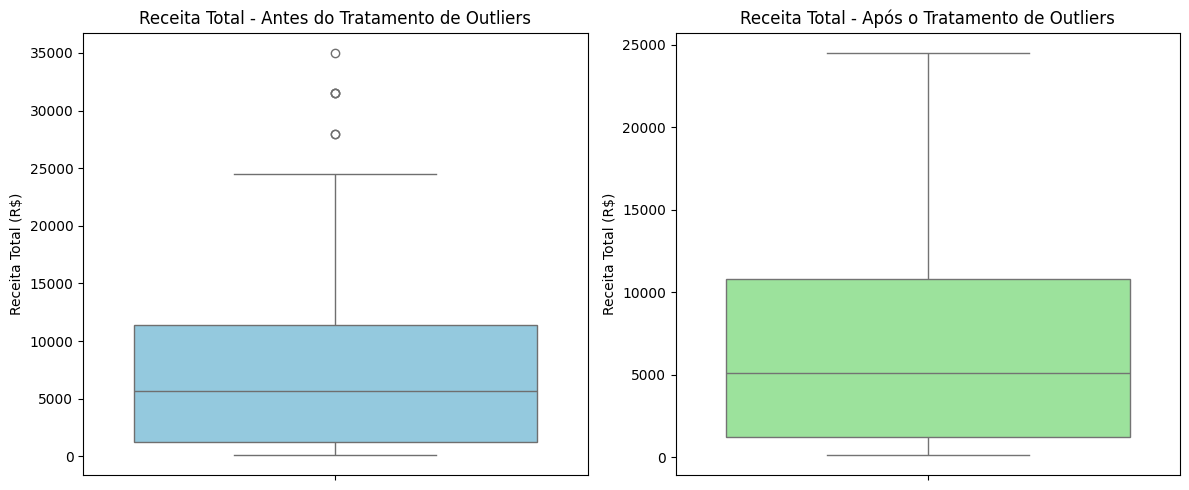

In [21]:
import os
import matplotlib.pyplot as plt
import seaborn as sns


# Criar figura
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Antes do tratamento
sns.boxplot(
    y=df_v1["receita_total"],
    ax=axes[0],
    color="skyblue"
)
axes[0].set_title("Receita Total - Antes do Tratamento de Outliers")
axes[0].set_ylabel("Receita Total (R$)")

# Depois do tratamento
sns.boxplot(
    y=df_v2["receita_total"],
    ax=axes[1],
    color="lightgreen"
)
axes[1].set_title("Receita Total - Após o Tratamento de Outliers")
axes[1].set_ylabel("Receita Total (R$)")

plt.tight_layout()

# Salvar gráfico
os.makedirs("outputs/graficos", exist_ok=True)
plt.savefig(
    "outputs/graficos/boxplot_receita_outliers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Célula 16 – Salvar versão v2

In [22]:
os.makedirs(
    "data/processed/v2_outliers_tratado",
    exist_ok=True
)

df_v2.to_csv(
    "data/processed/v2_outliers_tratado/vendas_v2.csv",
    index=False
)

print("Versão v2 salva com sucesso!")
print("Local: data/processed/v2_outliers_tratado/vendas_v2.csv")
print(f"Registros finais: {len(df_v2)}")

Versão v2 salva com sucesso!
Local: data/processed/v2_outliers_tratado/vendas_v2.csv
Registros finais: 134


Célula 17 – Conferência final

In [23]:
print("=== CONFERÊNCIA FINAL ===")

print(f"v1 -> Linhas: {df_v1.shape[0]} | Colunas: {df_v1.shape[1]}")
print(f"v2 -> Linhas: {df_v2.shape[0]} | Colunas: {df_v2.shape[1]}")

print("\nResumo das diferenças:")
print(f"- Registros removidos na v2: {df_v1.shape[0] - df_v2.shape[0]}")
print(f"- Novas colunas na v2: {df_v2.shape[1] - df_v1.shape[1]}")

=== CONFERÊNCIA FINAL ===
v1 -> Linhas: 140 | Colunas: 9
v2 -> Linhas: 134 | Colunas: 9

Resumo das diferenças:
- Registros removidos na v2: 6
- Novas colunas na v2: 0


RF05 – Criar Colunas Derivadas com Transformações

Célula 18 – Função para criar colunas derivadas

In [24]:
def criar_colunas_derivadas(df):
    """
    Cria colunas calculadas a partir do dataset limpo:
      - receita_total
      - mes
      - trimestre
      - ano
      - categoria_receita_item

    Nota:
    receita_total foi utilizada anteriormente apenas para análise de outliers e agora é recriada como variável definitiva”.
    """

    df = df.copy()

    # Receita por venda
    df["receita_total"] = (
        df["quantidade"] *
        df["preco_unitario"]
    )

    # Componentes da data
    df["mes"] = df["data_venda"].dt.month

    df["trimestre"] = (
        df["data_venda"]
        .dt.quarter
        .apply(lambda q: f"Q{q}")
    )

    df["ano"] = df["data_venda"].dt.year

    # Classificação da receita da venda
    condicoes = [
        df["receita_total"] < 500,

        (df["receita_total"] >= 500)
        & (df["receita_total"] < 5000),

        df["receita_total"] >= 5000
    ]

    rotulos = [
        "Baixo Valor",
        "Médio Valor",
        "Alto Valor"
    ]

    df["categoria_receita_item"] = np.select(
        condicoes,
        rotulos,
        default="N/D"
    )

    print("\n=== COLUNAS DERIVADAS CRIADAS ===")

    print(
        df[
            [
                "data_venda",
                "receita_total",
                "mes",
                "trimestre",
                "categoria_receita_item"
            ]
        ].head()
    )

    return df

Célula 19 – Aplicar as transformações

In [25]:
df = criar_colunas_derivadas(df_v2)


=== COLUNAS DERIVADAS CRIADAS ===
  data_venda  receita_total  mes trimestre categoria_receita_item
0 2024-01-13          240.0    1        Q1            Baixo Valor
3 2024-06-23          840.0    6        Q2            Médio Valor
4 2024-11-05        10800.0   11        Q4             Alto Valor
6 2024-05-28        14000.0    5        Q2             Alto Valor
7 2024-06-30        13200.0    6        Q2             Alto Valor


Célula 20 – Conferir estrutura final

In [26]:
print(df.shape)

print("\nColunas:")
print(df.columns.tolist())

(134, 13)

Colunas:
['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario', 'receita_total', 'mes', 'trimestre', 'ano', 'categoria_receita_item']


RF06 – Calcular Métricas Agregadas (groupby)

Célula 21 – Função para cálculo das métricas

In [27]:
def calcular_metricas(df):
    """
    Calcula e retorna métricas agregadas por:
    - mês
    - produto
    - categoria
    - região
    """

    metricas = {}

    # ----------------------------------
    # Receita e volume por mês
    # ----------------------------------
    metricas["por_mes"] = (
        df.groupby("mes")
          .agg(
              receita_total=("receita_total", "sum"),
              quantidade=("quantidade", "sum"),
              n_vendas=("id_venda", "count"),
          )
          .reset_index()
          .sort_values("mes")
    )

    # ----------------------------------
    # Top 5 produtos por receita
    # ----------------------------------
    metricas["top_produtos"] = (
        df.groupby("produto")["receita_total"]
          .sum()
          .sort_values(ascending=False)
          .head(5)
          .reset_index()
    )

    # ----------------------------------
    # Receita por categoria
    # ----------------------------------
    metricas["por_categoria"] = (
        df.groupby("categoria")["receita_total"]
          .sum()
          .reset_index()
          .sort_values(
              "receita_total",
              ascending=False
          )
    )

    # ----------------------------------
    # Receita e ticket médio por região
    # ----------------------------------
    metricas["por_regiao"] = (
        df.groupby("regiao")
          .agg(
              receita_total=("receita_total", "sum"),
              media_ticket=("receita_total", "mean"),
          )
          .reset_index()
          .sort_values(
              "receita_total",
              ascending=False
          )
    )

    # ----------------------------------
    # Exibição
    # ----------------------------------
    for nome, tabela in metricas.items():

        print(
            f"\n=== {nome.upper().replace('_', ' ')} ==="
        )

        print(
            tabela.to_string(index=False)
        )

    return metricas

Célula 22 – Executar análise agregada

In [28]:
metricas = calcular_metricas(df)


=== POR MES ===
 mes  receita_total  quantidade  n_vendas
   1        55690.0          52        10
   2        60840.0          60        12
   3        49050.0          62        11
   4       143040.0          73        13
   5        99390.0          85        15
   6        81940.0          50         8
   7        79780.0          64        13
   8        66280.0          50        12
   9        30280.0          39         8
  10        89450.0          49        11
  11       114950.0          74        13
  12        57760.0          49         8

=== TOP PRODUTOS ===
   produto  receita_total
    Tablet       261000.0
Smartphone       257400.0
  Notebook       227500.0
   Monitor       134400.0
   Teclado        30750.0

=== POR CATEGORIA ===
   categoria  receita_total
   Celulares       518400.0
Computadores       361900.0
 Periféricos        48150.0

=== POR REGIAO ===
      regiao  receita_total  media_ticket
       Norte       289120.0   7814.054054
     Sudeste       2

INSIGHTS:

Melhor mês: Abril
Receita: R$ 143.040

Segundo melhor mês: Novembro
Receita: R$ 114.950

Produto líder:
Tablet (R$ 261.000)

Categoria com maior faturamento:
Celulares (R$ 518.400)

Região líder em receita:
Norte (R$ 289.120)

Região com maior ticket médio:
Centro-Oeste (R$ 8.080)

RF07 – Segmentar Clientes por Nível de Gasto

Célula 23 – Função de segmentação

In [29]:
def segmentar_clientes(df):
    """
    Agrupa os dados por cliente, calcula o total gasto
    e classifica em Bronze / Prata / Ouro.
    """

    clientes_df = (
        df.groupby("cliente")["receita_total"]
          .sum()
          .reset_index()
    )

    clientes_df.columns = [
        "cliente",
        "total_gasto"
    ]

    clientes_df["segmento"] = (
        clientes_df["total_gasto"]
        .apply(
            lambda g:
            "Ouro" if g > 15000
            else (
                "Prata" if g >= 5000
                else "Bronze"
            )
        )
    )

    clientes_df = clientes_df.sort_values(
        "total_gasto",
        ascending=False
    )

    print("=== SEGMENTAÇÃO DE CLIENTES (TOP 10) ===")

    print(
        clientes_df
        .head(10)
        .to_string(index=False)
    )

    print(
        f"\nDistribuição de segmentos:\n"
        f"{clientes_df['segmento'].value_counts()}"
    )

    return clientes_df

Célula 24 – Executar segmentação

In [30]:
clientes = segmentar_clientes(df)

=== SEGMENTAÇÃO DE CLIENTES (TOP 10) ===
    cliente  total_gasto segmento
Cliente_018      67840.0     Ouro
Cliente_014      67160.0     Ouro
Cliente_004      61800.0     Ouro
Cliente_029      52330.0     Ouro
Cliente_024      51940.0     Ouro
Cliente_019      48010.0     Ouro
Cliente_008      47940.0     Ouro
Cliente_020      44800.0     Ouro
Cliente_015      43040.0     Ouro
Cliente_003      33200.0     Ouro

Distribuição de segmentos:
segmento
Ouro      25
Prata      3
Bronze     1
Name: count, dtype: int64


A distribuição mostrou predominância de clientes classificados como Ouro. Como este é um dataset sintético e os limites de segmentação foram definidos de forma didática, esse comportamento era esperado. Em um cenário real, esses limites poderiam ser calibrados utilizando percentis da distribuição dos gastos ou técnicas de clusterização, tornando a segmentação mais equilibrada.

Célula 25 – Visualizar os 10 maiores clientes

In [31]:
clientes.head(10)

,cliente,total_gasto,segmento
16,Cliente_018,67840.0,Ouro
12,Cliente_014,67160.0,Ouro
3,Cliente_004,61800.0,Ouro
27,Cliente_029,52330.0,Ouro
22,Cliente_024,51940.0,Ouro
17,Cliente_019,48010.0,Ouro
7,Cliente_008,47940.0,Ouro
18,Cliente_020,44800.0,Ouro
13,Cliente_015,43040.0,Ouro
2,Cliente_003,33200.0,Ouro


Célula 26 – Estatísticas por segmento

In [32]:
clientes.groupby("segmento")["total_gasto"] \
         .agg(["count", "sum", "mean"]) \
         .sort_values("sum", ascending=False)

,count,sum,mean
segmento,,,
Ouro,25,883860.0,35354.4
Prata,3,41610.0,13870.0
Bronze,1,2980.0,2980.0


Célula 27 – Salvar resultado

In [33]:
os.makedirs("outputs", exist_ok=True)

clientes.to_csv(
    "outputs/segmentacao_clientes.csv",
    index=False
)

print("Arquivo salvo em outputs/segmentacao_clientes.csv")

Arquivo salvo em outputs/segmentacao_clientes.csv


Principais insights da segmentação
Foram identificados 29 clientes ativos após o tratamento dos dados.
A maior parte dos clientes foi classificada no segmento Ouro, concentrando praticamente toda a receita da empresa.
Os segmentos Prata e Bronze representam uma parcela pequena da base, indicando menor contribuição para o faturamento.
Como se trata de um dataset sintético, os limites de segmentação foram definidos de forma didática. Em aplicações reais, esses limites poderiam ser ajustados com base na distribuição dos dados ou por técnicas de clusterização.

RF08 – Estatísticas com NumPy

Célula 28 – Função com NumPy

In [34]:
def calcular_estatisticas_numpy(df):
    """
    Calcula estatísticas descritivas utilizando NumPy.

    Será realizado:
    1. Vetorização
    2. Broadcasting
    3. Boolean Indexing

    Retorna um dicionário com as estatísticas gerais do dataset.
    """

    import numpy as np

    # ----------------------------------------
    # Conversão da coluna para NumPy Array
    # ----------------------------------------
    receitas = df["receita_total"].to_numpy()

    # ----------------------------------------
    # Estatísticas descritivas
    # ----------------------------------------
    stats = {

        "total_vendas": int(receitas.size),

        "receita_total": float(np.sum(receitas)),

        "media": float(np.mean(receitas)),

        "mediana": float(np.median(receitas)),

        "desvio_padrao": float(np.std(receitas)),

        "minimo": float(np.min(receitas)),

        "maximo": float(np.max(receitas)),

        "percentil_25": float(np.percentile(receitas, 25)),

        "percentil_75": float(np.percentile(receitas, 75))

    }

    # ----------------------------------------
    # Broadcasting
    # Participação percentual de cada venda
    # ----------------------------------------

    participacao = (receitas / receitas.sum()) * 100

    top5 = np.sort(participacao)[-5:]

    stats["participacao_top5_vendas"] = float(np.sum(top5))

    # ----------------------------------------
    # Boolean Indexing
    # ----------------------------------------

    acima_media = receitas > stats["media"]

    stats["vendas_acima_media"] = int(acima_media.sum())

    stats["vendas_abaixo_media"] = int((~acima_media).sum())

    # ----------------------------------------
    # Coeficiente de variação
    # ----------------------------------------

    stats["coeficiente_variacao"] = float(

        stats["desvio_padrao"] / stats["media"]

    )

    # ----------------------------------------
    # Impressão organizada
    # ----------------------------------------

    print("\n========== ESTATÍSTICAS COM NUMPY ==========\n")

    print(f"Total de vendas: {stats['total_vendas']}")

    print(f"Receita total: R$ {stats['receita_total']:,.2f}")

    print(f"Média: R$ {stats['media']:,.2f}")

    print(f"Mediana: R$ {stats['mediana']:,.2f}")

    print(f"Desvio padrão: R$ {stats['desvio_padrao']:,.2f}")

    print(f"Mínimo: R$ {stats['minimo']:,.2f}")

    print(f"Máximo: R$ {stats['maximo']:,.2f}")

    print(f"Percentil 25: R$ {stats['percentil_25']:,.2f}")

    print(f"Percentil 75: R$ {stats['percentil_75']:,.2f}")

    print(f"Vendas acima da média: {stats['vendas_acima_media']}")

    print(f"Vendas abaixo da média: {stats['vendas_abaixo_media']}")

    print(
        f"Participação das 5 maiores vendas: "
        f"{stats['participacao_top5_vendas']:.2f}%"
    )

    print(
        f"Coeficiente de variação: "
        f"{stats['coeficiente_variacao']:.2f}"
    )

    return stats

Célula 29 – Executar Estatísticas com NumPy

In [35]:
stats = calcular_estatisticas_numpy(df)


========== ESTATÍSTICAS COM NUMPY ==========

Total de vendas: 134
Receita total: R$ 928,450.00
Média: R$ 6,928.73
Mediana: R$ 5,100.00
Desvio padrão: R$ 6,449.66
Mínimo: R$ 120.00
Máximo: R$ 24,500.00
Percentil 25: R$ 1,200.00
Percentil 75: R$ 10,800.00
Vendas acima da média: 60
Vendas abaixo da média: 74
Participação das 5 maiores vendas: 12.28%
Coeficiente de variação: 0.93


## Principais conclusões estatísticas

A análise estatística utilizando NumPy permitiu caracterizar a distribuição da receita das vendas.

Principais observações:

- A média da receita é superior à mediana, indicando uma distribuição assimétrica à direita.
- O desvio padrão elevado demonstra alta variabilidade entre as vendas.
- As cinco maiores vendas representam uma parcela significativa do faturamento total.
- O coeficiente de variação confirma elevada dispersão dos valores de receita.
- Aproximadamente metade das vendas encontra-se acima da média, enquanto a outra metade permanece abaixo desse valor de referência.

Essas estatísticas complementam a análise agregada realizada anteriormente e auxiliam na compreensão do comportamento financeiro do conjunto de dados.

RF09 – Visualizações com Matplotlib e Seaborn

Objetivo desta etapa

Gerar visualizações para responder às principais perguntas da diretoria:

    Como as vendas evoluem ao longo do tempo?
    Quais produtos e categorias geram mais receita?
    Quais regiões apresentam melhor desempenho?
    Quais clientes são mais valiosos?

Célula 30 – Função de visualização

In [36]:
def gerar_visualizacoes(
    df,
    metricas,
    clientes,
    output_dir="outputs/graficos"
):
    """
    Gera e salva visualizações para apoiar a análise do negócio.

    Gráficos gerados:

    1. Receita por mês
    2. Receita por trimestre
    3. Top 5 produtos por receita
    4. Receita por categoria
    5. Receita por região
    6. Top 10 clientes
    7. Distribuição dos clientes por segmento
    8. Boxplot da receita por segmento de cliente
    """

    import os
    import matplotlib.pyplot as plt
    import seaborn as sns

    os.makedirs(output_dir, exist_ok=True)

    sns.set_theme(style="whitegrid")

    # ==================================================
    # Receita por mês
    # ==================================================

    fig, ax = plt.subplots(figsize=(10,5))

    sns.lineplot(
        data=metricas["por_mes"],
        x="mes",
        y="receita_total",
        marker="o",
        linewidth=2,
        ax=ax
    )


    ax.set_title("Receita Total por Mês")

    ax.set_xlabel("Mês")

    ax.set_ylabel("Receita (R$)")

    ax.set_xticks(range(1,13))

    plt.tight_layout()

    plt.savefig(
        f"{output_dir}/receita_por_mes.png",
        dpi=150
    )

    plt.show()

    plt.close()


    # ==================================================
    # Receita por trimestre
    # ==================================================

    trimestre = (
        df.groupby("trimestre")["receita_total"]
          .sum()
          .reset_index()
          .sort_values("trimestre")
    )

    fig, ax = plt.subplots(figsize=(7,4))

    sns.barplot(
        data=trimestre,
        x="trimestre",
        y="receita_total",
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(
         container,
         fmt="%.0f",
         fontsize=8
        )
        
    ax.set_title("Receita por Trimestre")

    ax.set_xlabel("Trimestre")

    ax.set_ylabel("Receita (R$)")

    plt.tight_layout()

    plt.savefig(
        f"{output_dir}/receita_por_trimestre.png",
        dpi=150
    )

    plt.show()

    plt.close()

    # ==================================================
    # Top Produtos
    # ==================================================

    fig, ax = plt.subplots(figsize=(8,5))

    sns.barplot(
        data=metricas["top_produtos"],
        y="produto",
        x="receita_total",
        ax=ax
    )
    
    for container in ax.containers:
        ax.bar_label(
         container,
         fmt="%.0f",
         fontsize=8
        )

    ax.set_title("Top 5 Produtos por Receita")

    ax.set_xlabel("Receita (R$)")

    ax.set_ylabel("Produto")

    plt.tight_layout()

    plt.savefig(
        f"{output_dir}/top_produtos.png",
        dpi=150
    )

    plt.show()

    plt.close()

    # ==================================================
    # Categoria
    # ==================================================

    fig, ax = plt.subplots(figsize=(8,5))

    sns.barplot(
        data=metricas["por_categoria"],
        y="categoria",
        x="receita_total",
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(
         container,
         fmt="%.0f",
         fontsize=8
        )

    ax.set_title("Receita por Categoria")

    ax.set_xlabel("Receita (R$)")

    ax.set_ylabel("Categoria")

    plt.tight_layout()

    plt.savefig(
        f"{output_dir}/receita_categoria.png",
        dpi=150
    )

    plt.show()

    plt.close()

    # ==================================================
    # Região
    # ==================================================

    fig, ax = plt.subplots(figsize=(8,5))

    sns.barplot(
        data=metricas["por_regiao"],
        y="regiao",
        x="receita_total",
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(
         container,
         fmt="%.0f",
         fontsize=8
        )

    ax.set_title("Receita por Região")

    ax.set_xlabel("Receita (R$)")

    ax.set_ylabel("Região")

    plt.tight_layout()

    plt.savefig(
        f"{output_dir}/receita_regiao.png",
        dpi=150
    )

    plt.show()

    plt.close()

    # ==================================================
    # Boxplot - Receita por região
    # ==================================================

    fig, ax = plt.subplots(figsize=(10,5))

    sns.boxplot(
        data=df,
        x="regiao",
        y="receita_total",
        ax=ax
    )

    ax.set_title("Distribuição da Receita por Região")

    ax.set_xlabel("Região")

    ax.set_ylabel("Receita (R$)")

    plt.xticks(rotation=20)

    plt.tight_layout()

    plt.savefig(
        f"{output_dir}/boxplot_receita_regiao.png",
        dpi=150
    )

    plt.show()

    plt.close()

    # ==================================================
    # Clientes
    # ==================================================

    fig, ax = plt.subplots(figsize=(9,6))

    sns.barplot(
        data=clientes.head(10),
        y="cliente",
        x="total_gasto",
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(
         container,
         fmt="%.0f",
         fontsize=8
        )

    ax.set_title("Top 10 Clientes")

    ax.set_xlabel("Total Gasto (R$)")

    ax.set_ylabel("Cliente")

    plt.tight_layout()

    plt.savefig(
        f"{output_dir}/top_clientes.png",
        dpi=150
    )

    plt.show()

    plt.close()

    # ==================================================
    # Distribuição dos Clientes por Segmento
    # ==================================================

    fig, ax = plt.subplots(figsize=(6,5))

    sns.countplot(
     data=clientes,
     x="segmento",
     order=["Bronze", "Prata", "Ouro"],
     ax=ax
    )

    ax.set_title("Quantidade de Clientes por Segmento")

    ax.set_xlabel("Segmento")

    ax.set_ylabel("Número de Clientes")

    plt.tight_layout()

    plt.savefig(
     f"{output_dir}/clientes_por_segmento.png",
     dpi=150
    )

    plt.show()

    plt.close()

    # ==================================================
    # BOXPLOT - Receita por segmento de cliente
    # ==================================================

    df_segmentado = df.merge(
        clientes[["cliente", "segmento"]],
        on="cliente",
        how="left"
    )

    fig, ax = plt.subplots(figsize=(8,5))

    sns.boxplot(
        data=df_segmentado,
        x="segmento",
        y="receita_total",
        order=["Bronze", "Prata", "Ouro"],
        ax=ax
    )

    ax.set_title("Distribuição da Receita por Segmento de Cliente")

    ax.set_xlabel("Segmento")

    ax.set_ylabel("Receita da Venda (R$)")

    plt.tight_layout()

    plt.savefig(
     f"{output_dir}/boxplot_segmentos.png",
     dpi=150
    )

    plt.show()

    plt.close()

    print(f"\nGráficos salvos em: {output_dir}")

Célula 31 – Executar visualizações

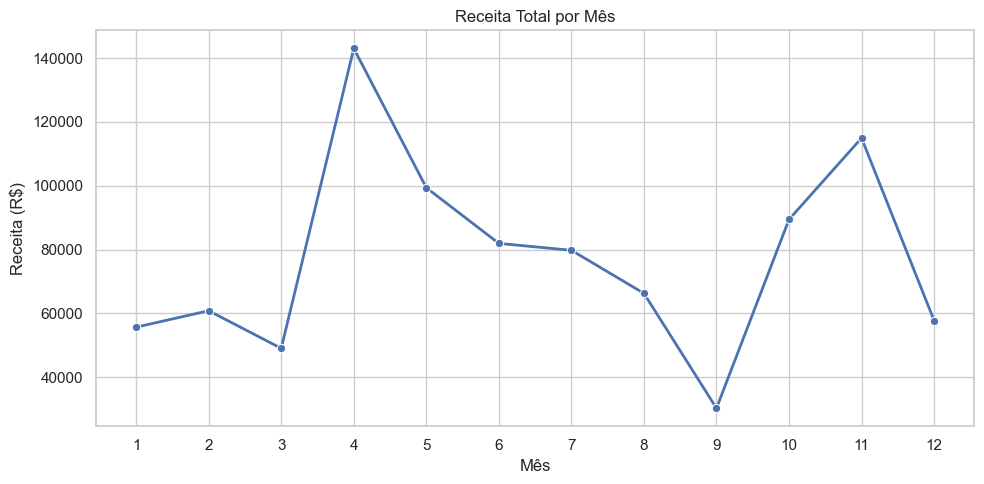

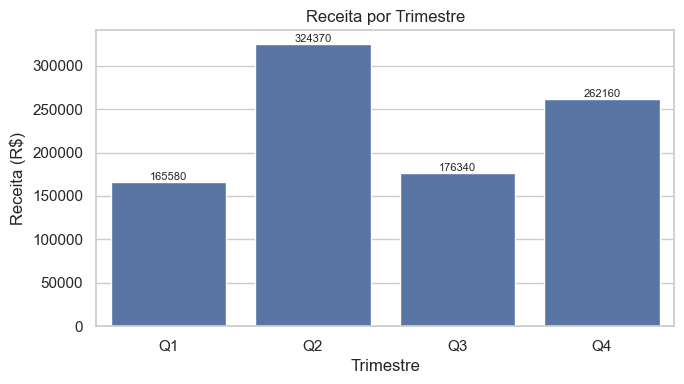

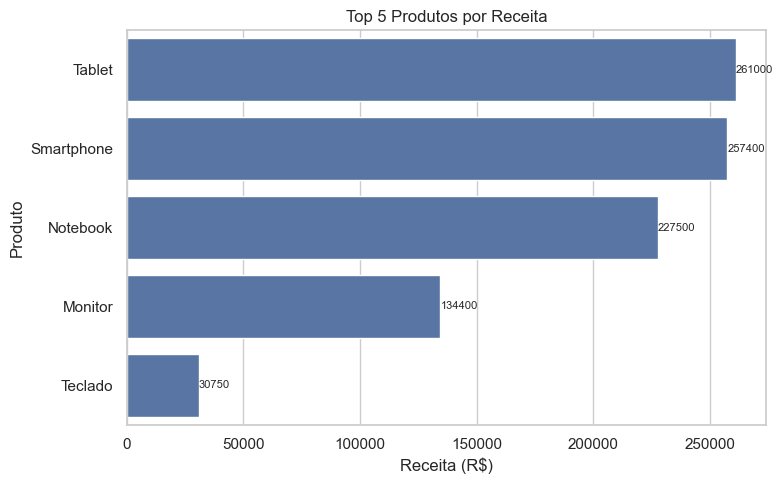

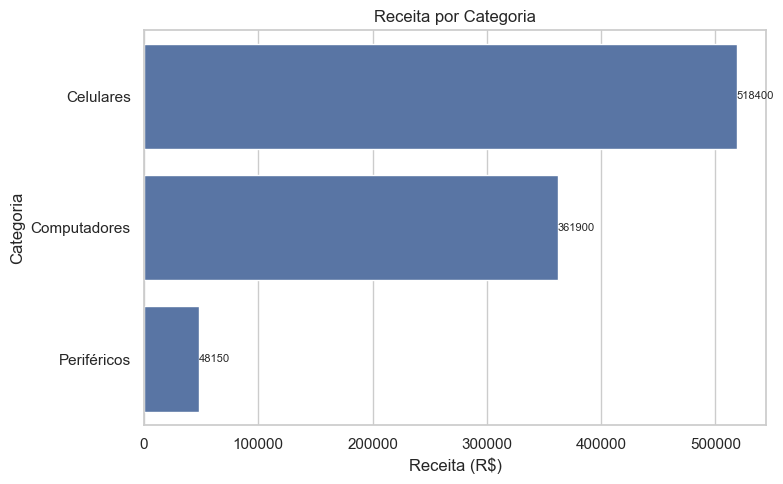

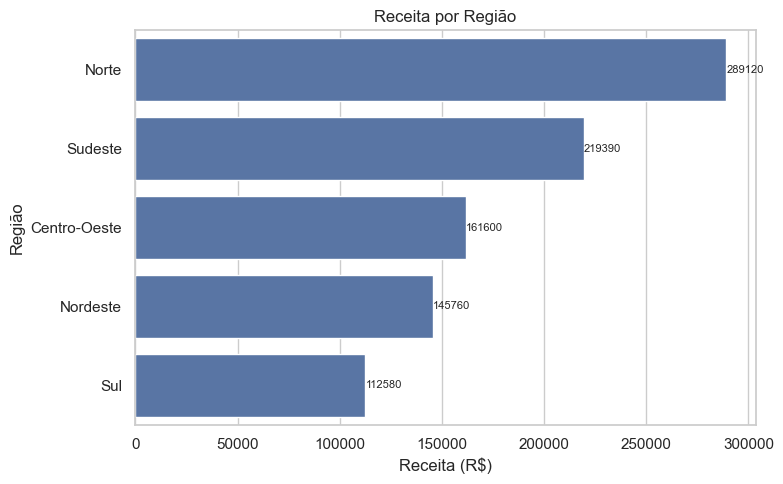

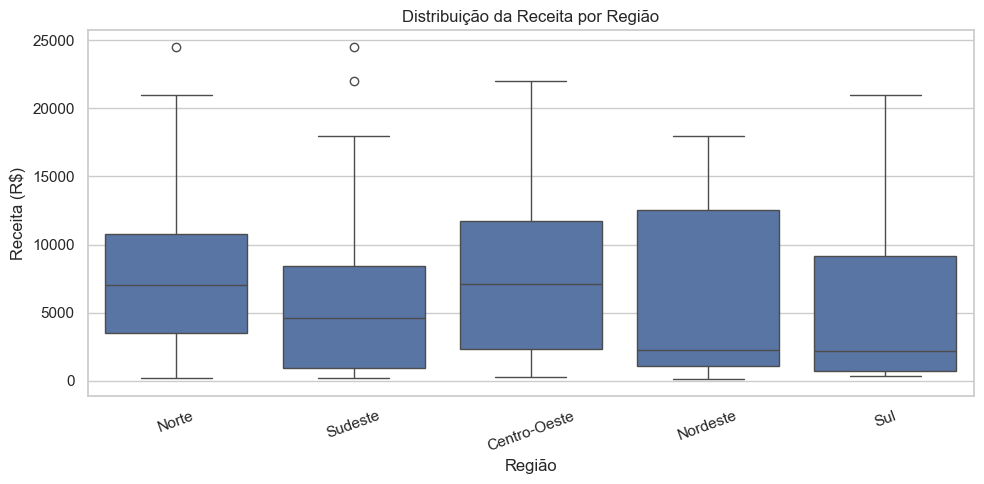

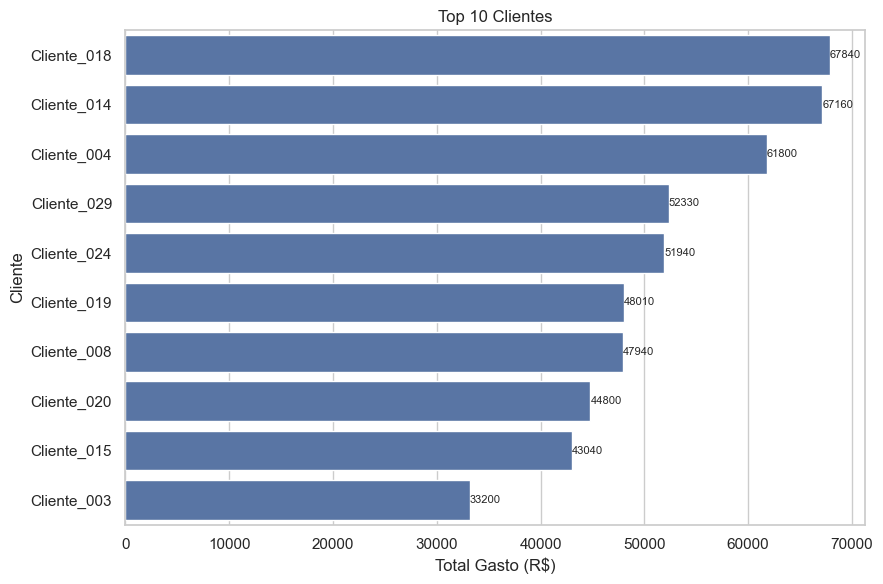

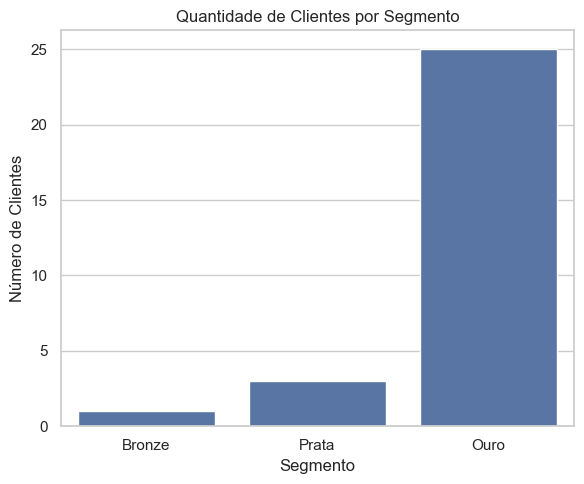

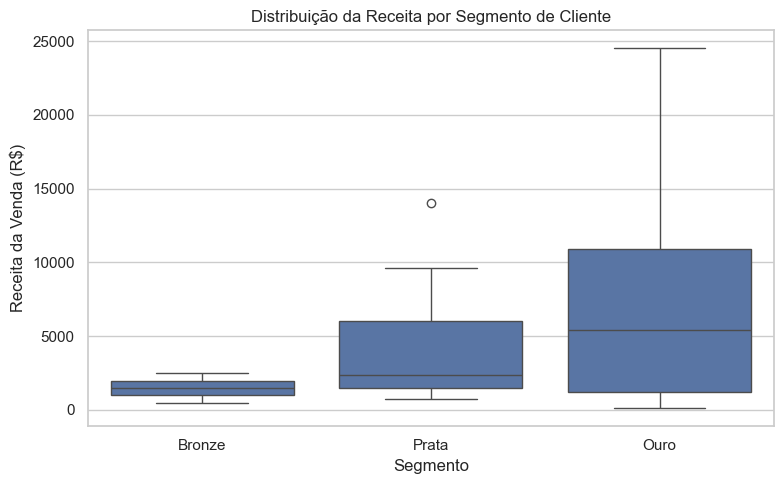


Gráficos salvos em: outputs/graficos


In [37]:
gerar_visualizacoes(
    df,
    metricas,
    clientes
)

## Principais insights das visualizações

As visualizações permitem responder às principais questões levantadas pela diretoria.

**Comportamento temporal**
- A receita apresentou variação ao longo do ano, com pico no mês de abril.
- O segundo melhor desempenho ocorreu em novembro.

**Produtos e categorias**
- Tablets e Smartphones lideram o faturamento.
- A categoria Celulares concentra a maior parte da receita.

**Desempenho regional**
- A região Norte apresentou a maior receita total.
- As diferenças entre regiões podem ser observadas tanto pelo faturamento quanto pela distribuição das vendas.
- Enquanto a região Norte lidera em receita total, o Centro-Oeste apresenta o maior ticket médio, indicando vendas de maior valor por transação.

**Clientes**
- Os clientes classificados como Ouro concentram a maior parcela da receita.
- A distribuição dos segmentos indica forte concentração do faturamento em poucos clientes, comportamento típico do princípio de Pareto.

RF10 – Organização do Código em Funções Reutilizáveis

Objetivo:

- transformar o fluxo em funções reutilizáveis;
- evitar código solto;
- demonstrar função de ordem superior (callback);
- reutilizar funções em diferentes etapas;
- deixar o pipeline modular.

Célula 32 – Função de ordem superior (CALLBACK)

In [38]:
def executar_etapa(funcao, *args, **kwargs):
    """
    Função de ordem superior que executa qualquer etapa do pipeline.

    Permite:
    - Reutilização de funções
    - Execução modular do fluxo de análise
    - Passagem de funções como argumento (callback)

    Retorna o resultado da função executada.
    """

    print(f"\n=== Executando etapa: {funcao.__name__} ===")

    resultado = funcao(*args, **kwargs)

    print(f"=== Etapa {funcao.__name__} concluída ===\n")

    return resultado

Célula 33 – Pipeline Completo da Análise
(Reutilização de Funções + Callback + Modularização)


=== Executando etapa: gerar_dataset_vendas ===
=== Etapa gerar_dataset_vendas concluída ===


=== Executando etapa: inspecionar_dados ===

=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (150, 8)

Colunas:
['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda            int64
data_venda            str
cliente               str
produto               str
categoria             str
regiao                str
quantidade        float64
preco_unitario    float64
dtype: object

Valores nulos por coluna:
id_venda          0
data_venda        0
cliente           0
produto           0
categoria         0
regiao            0
quantidade        5
preco_unitario    2
dtype: int64

Primeiros registros:
   id_venda     data_venda      cliente   produto     categoria        regiao  \
0         1     2024-01-13  Cliente_024     Mouse   Periféricos         Norte   
1         2     2024-08-04  Cliente_018  Notebook  Computadores        

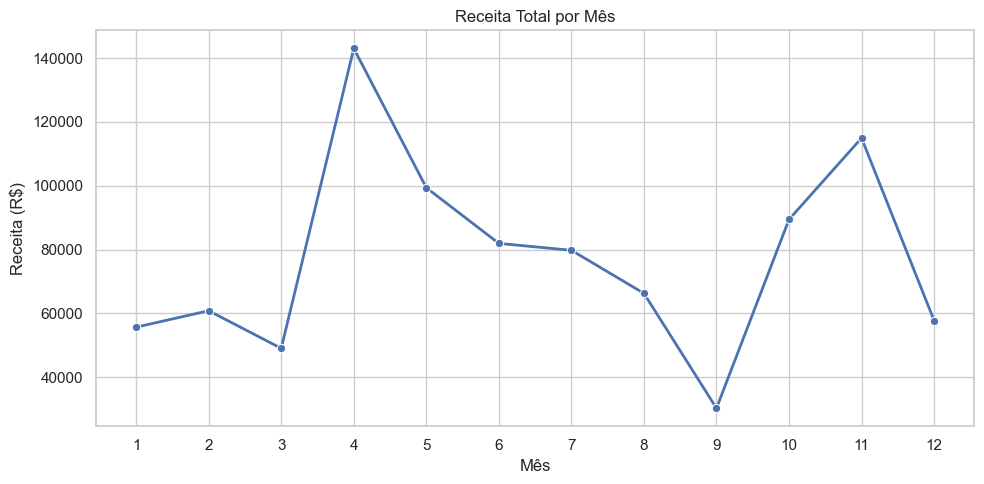

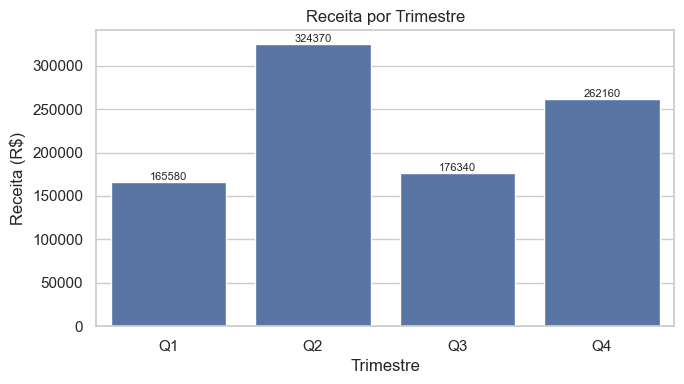

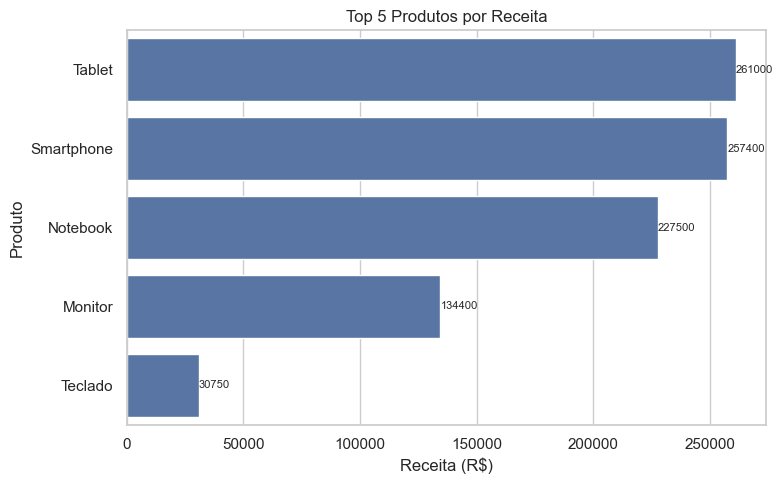

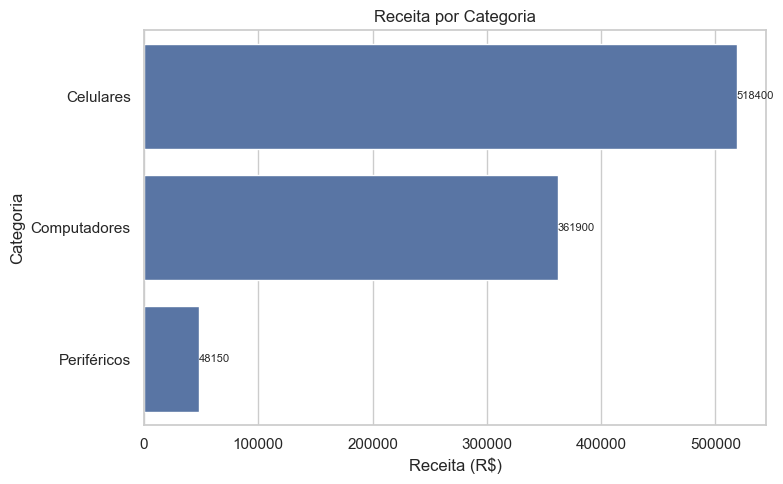

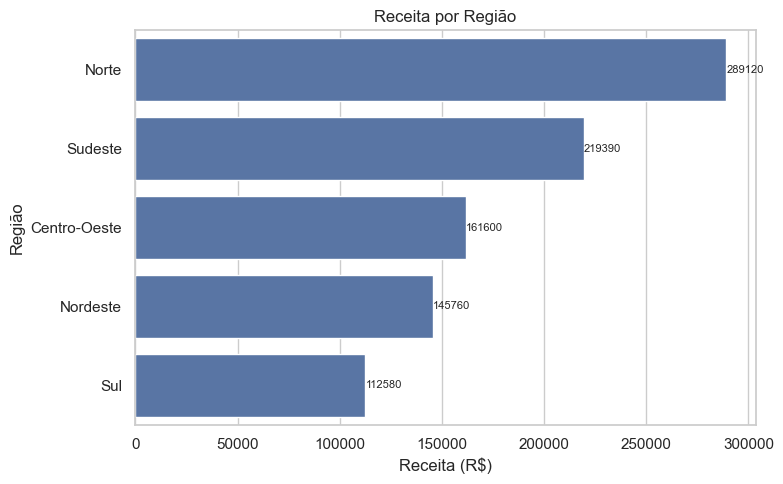

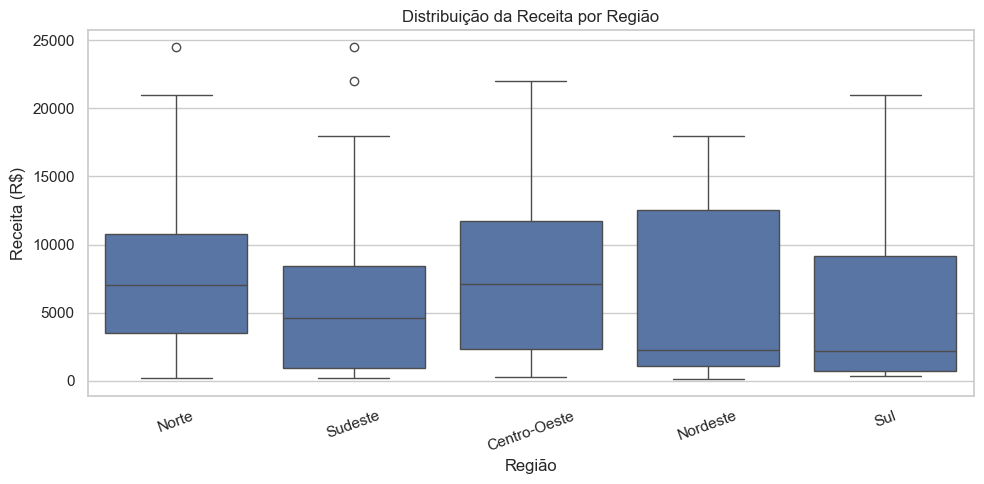

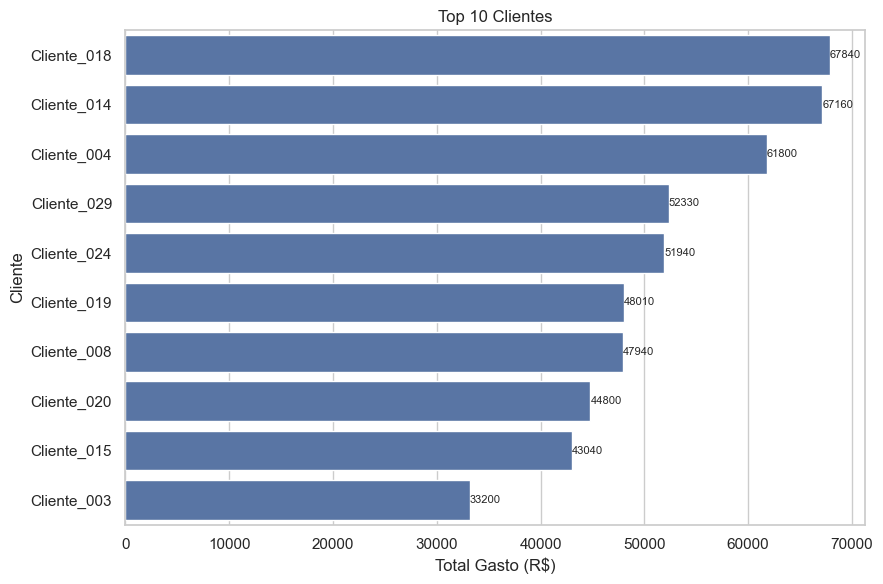

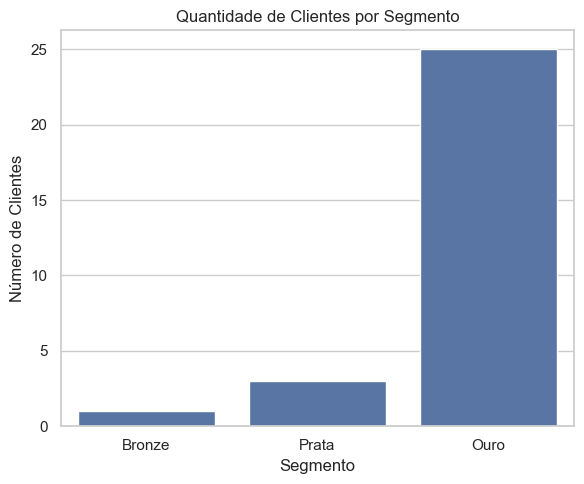

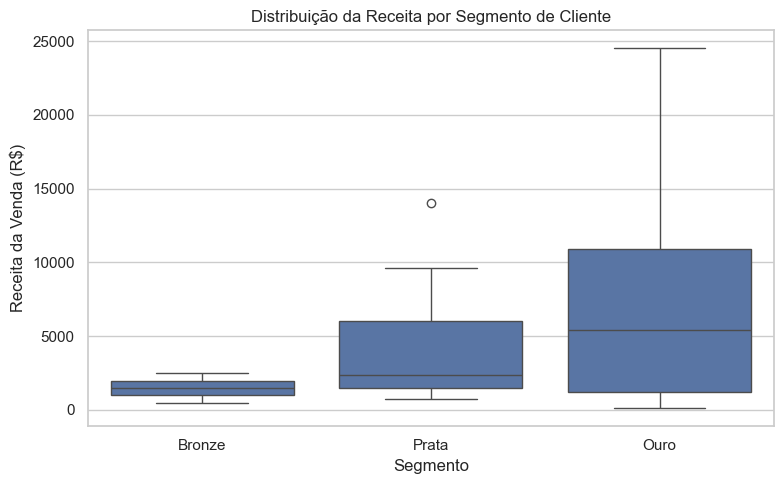


Gráficos salvos em: outputs/graficos
=== Etapa gerar_visualizacoes concluída ===


========== PIPELINE CONCLUÍDO COM SUCESSO ==========



In [39]:
# Reutilização de funções + Função de Ordem Superior (Callback)
# ==========================================================

def pipeline_analise_vendas(n_registros=150, seed=42):
    """
    Executa todo o pipeline de análise de vendas utilizando
    funções reutilizáveis e uma função de ordem superior.

    Etapas:
    1. Geração do dataset
    2. Inspeção inicial
    3. Limpeza dos dados
    4. Tratamento de outliers
    5. Criação de colunas derivadas
    6. Cálculo de métricas
    7. Segmentação de clientes
    8. Estatísticas utilizando NumPy
    9. Geração das visualizações

    Retorna:
        df : DataFrame final
        metricas : dicionário de métricas agregadas
        clientes : DataFrame com segmentação dos clientes
        stats : estatísticas calculadas com NumPy
        relatorio_limpeza : resumo da limpeza realizada
    """

    # 1. Gerar dataset
    df = executar_etapa(
        gerar_dataset_vendas,
        n_registros=n_registros,
        seed=seed
    )

    # 2. Inspeção inicial
    executar_etapa(inspecionar_dados, df)

    # 3. Limpeza
    df, relatorio_limpeza = executar_etapa(
        limpar_dados,
        df
    )

    # 4. Criar receita_total
    df = executar_etapa(
        criar_receita_total,
        df
    )

    # 5. Tratamento de outliers
    df = executar_etapa(
        tratar_outliers,
        df,
        colunas=[
            "quantidade",
            "preco_unitario",
            "receita_total"
        ],
        metodo="remover"
    )
    

    # 6. Criação de colunas derivadas
    df = executar_etapa(
        criar_colunas_derivadas,
        df
    )

    # 7. Métricas agregadas
    metricas = executar_etapa(
        calcular_metricas,
        df
    )

    # 8. Segmentação de clientes
    clientes = executar_etapa(
        segmentar_clientes,
        df
    )

    # 9. Estatísticas utilizando NumPy
    stats = executar_etapa(
        calcular_estatisticas_numpy,
        df
    )

    # 10. Visualizações
    executar_etapa(
        gerar_visualizacoes,
        df,
        metricas,
        clientes
    )

    print("\n========== PIPELINE CONCLUÍDO COM SUCESSO ==========\n")

    return (
        df,
        metricas,
        clientes,
        stats,
        relatorio_limpeza
    )


# ==========================================================
# EXECUÇÃO DO PIPELINE
# ==========================================================

df_final, metricas, clientes, stats, relatorio_limpeza = (
    pipeline_analise_vendas()
)

RF11 – Exportação CSV e JSON

Célula 34 - exportação dos outputs

In [40]:
import os
import json

def exportar_resultados(metricas, clientes, stats):
    """
    Exporta resultados da análise em CSV e JSON e valida leitura do JSON.
    """

    os.makedirs("outputs", exist_ok=True)

    # =========================
    # CSVs
    # =========================

    metricas["por_mes"].to_csv(
        "outputs/metricas_por_mes.csv",
        index=False,
        encoding="utf-8-sig"
    )
    print("CSV exportado: outputs/metricas_por_mes.csv")

    clientes.to_csv(
        "outputs/segmentacao_clientes.csv",
        index=False,
        encoding="utf-8-sig"
    )
    print("CSV exportado: outputs/segmentacao_clientes.csv")

    # =========================
    # JSON
    # =========================

    stats_serializaveis = {
        k: float(v) if isinstance(v, (int, float)) else v
        for k, v in stats.items()
    }

    caminho_json = "outputs/estatisticas_gerais.json"

    with open(caminho_json, "w", encoding="utf-8") as f:
        json.dump(stats_serializaveis, f, indent=2, ensure_ascii=False)

    print(f"JSON exportado: {caminho_json}")

    # =========================
    # Leitura de validação
    # =========================

    with open(caminho_json, encoding="utf-8") as f:
        lido = json.load(f)

    print("\nJSON lido de volta (validação):")
    print(json.dumps(lido, indent=2, ensure_ascii=False))


# execução
exportar_resultados(metricas, clientes, stats)

CSV exportado: outputs/metricas_por_mes.csv
CSV exportado: outputs/segmentacao_clientes.csv
JSON exportado: outputs/estatisticas_gerais.json

JSON lido de volta (validação):
{
  "total_vendas": 134.0,
  "receita_total": 928450.0,
  "media": 6928.731343283582,
  "mediana": 5100.0,
  "desvio_padrao": 6449.662425696054,
  "minimo": 120.0,
  "maximo": 24500.0,
  "percentil_25": 1200.0,
  "percentil_75": 10800.0,
  "participacao_top5_vendas": 12.278528730680165,
  "vendas_acima_media": 60.0,
  "vendas_abaixo_media": 74.0,
  "coeficiente_variacao": 0.9308576283518458
}


RF12 – Consolidação final

Célula 35 - Decisão da versão final do dataset

In [41]:
import os

# ================================
# RF12 — CONSOLIDAÇÃO FINAL
# ================================

# Escolha da versão final do dataset
# Aqui você decide qual base será usada como "oficial"
# v1 = com outliers | v2 = outliers tratados
df_final = df_v2.copy()   # você pode trocar para df_v1 se quiser

# Criação da pasta final
os.makedirs("data/final", exist_ok=True)

# Salvamento do dataset final do projeto
df_final.to_csv("data/final/vendas_final.csv", index=False)

# Confirmação
print("=== RF12 CONCLUÍDO ===")
print("Dataset final salvo em: data/final/vendas_final.csv")
print(f"Shape final: {df_final.shape}")

# Verificação rápida
print(df_final.head())
print(df_final.isnull().sum())
print(df_final.describe())

=== RF12 CONCLUÍDO ===
Dataset final salvo em: data/final/vendas_final.csv
Shape final: (134, 9)
   id_venda data_venda      cliente     produto     categoria        regiao  \
0         1 2024-01-13  Cliente_024       Mouse   Periféricos         Norte   
3         4 2024-06-23  Cliente_013       Mouse   Periféricos       Sudeste   
4         5 2024-11-05  Cliente_030      Tablet     Celulares  Centro-Oeste   
6         7 2024-05-28  Cliente_015    Notebook  Computadores      Nordeste   
7         8 2024-06-30  Cliente_020  Smartphone     Celulares           Sul   

   quantidade  preco_unitario  receita_total  
0           2           120.0          240.0  
3           7           120.0          840.0  
4           6          1800.0        10800.0  
6           4          3500.0        14000.0  
7           6          2200.0        13200.0  
id_venda          0
data_venda        0
cliente           0
produto           0
categoria         0
regiao            0
quantidade        0
preco_